In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("flight_data_500.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (500, 9)


In [3]:
df.head()

,Airline,Source,Destination,Departure_Time,Duration_Hours,Total_Stops,Days_Left,Class,Price
0,Vistara,Kolkata,Hyderabad,Night,5.2,2,58,Economy,10590
1,Air India,Hyderabad,Chennai,Night,6.8,1,2,Economy,14384
2,SpiceJet,Chennai,Delhi,Afternoon,4.7,0,49,Economy,7204
3,SpiceJet,Kolkata,Bangalore,Evening,7.9,0,3,Business,20331
4,Air India,Chennai,Delhi,Night,7.6,1,50,Economy,11110


In [4]:
df.tail()

,Airline,Source,Destination,Departure_Time,Duration_Hours,Total_Stops,Days_Left,Class,Price
495,SpiceJet,Chennai,Hyderabad,Morning,1.2,2,21,Business,15038
496,AirAsia,Hyderabad,Kolkata,Morning,7.1,1,49,Economy,9331
497,AirAsia,Delhi,Mumbai,Morning,3.1,1,27,Economy,8839
498,Air India,Hyderabad,Bangalore,Evening,7.4,2,37,Economy,11917
499,IndiGo,Mumbai,Bangalore,Afternoon,8.0,1,29,Economy,12409


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Airline         500 non-null    object 
 1   Source          500 non-null    object 
 2   Destination     500 non-null    object 
 3   Departure_Time  500 non-null    object 
 4   Duration_Hours  500 non-null    float64
 5   Total_Stops     500 non-null    int64  
 6   Days_Left       500 non-null    int64  
 7   Class           500 non-null    object 
 8   Price           500 non-null    int64  
dtypes: float64(1), int64(3), object(5)
memory usage: 35.3+ KB


In [6]:
df.isnull().sum()

Airline           0
Source            0
Destination       0
Departure_Time    0
Duration_Hours    0
Total_Stops       0
Days_Left         0
Class             0
Price             0
dtype: int64

In [7]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (500, 9)


In [10]:
df.dtypes

Airline            object
Source             object
Destination        object
Departure_Time     object
Duration_Hours    float64
Total_Stops         int64
Days_Left           int64
Class              object
Price               int64
dtype: object

In [11]:
df.describe()

,Duration_Hours,Total_Stops,Days_Left,Price
count,500.000000,500.00000,500.00000,500.000000
mean,4.470600,0.96400,29.36800,10832.814000
std,2.052877,0.79999,17.47373,3168.848262
min,1.000000,0.00000,1.00000,4782.000000
25%,2.700000,0.00000,14.00000,8631.750000
50%,4.500000,1.00000,28.00000,10443.500000
75%,6.300000,2.00000,44.00000,12199.000000
max,8.000000,2.00000,60.00000,21053.000000


In [12]:
categorical_columns = [
    "Airline",
    "Source",
    "Destination",
    "Departure_Time",
    "Class"
]

for column in categorical_columns:
    print("\n", column)
    print(df[column].value_counts())


 Airline
Airline
SpiceJet     113
AirAsia      101
IndiGo        98
Vistara       94
Air India     94
Name: count, dtype: int64

 Source
Source
Chennai      94
Kolkata      87
Delhi        87
Bangalore    83
Hyderabad    78
Mumbai       71
Name: count, dtype: int64

 Destination
Destination
Delhi        93
Kolkata      92
Hyderabad    91
Mumbai       78
Bangalore    74
Chennai      72
Name: count, dtype: int64

 Departure_Time
Departure_Time
Afternoon    137
Morning      126
Night        119
Evening      118
Name: count, dtype: int64

 Class
Class
Economy     434
Business     66
Name: count, dtype: int64


In [13]:
df.groupby("Airline")["Price"].mean().sort_values()

Airline
SpiceJet     10196.539823
IndiGo       10847.581633
AirAsia      10877.920792
Vistara      11134.425532
Air India    11232.223404
Name: Price, dtype: float64

In [14]:
df.groupby("Class")["Price"].mean()

Class
Business    16854.969697
Economy      9917.002304
Name: Price, dtype: float64

In [15]:
df.groupby("Total_Stops")["Price"].mean()

Total_Stops
0    10158.195266
1    10817.622222
2    11605.960265
Name: Price, dtype: float64

In [16]:
df.groupby("Days_Left")["Price"].mean().head(10)

Days_Left
1     13932.600000
2     14014.750000
3     12884.764706
4     12718.545455
5     13226.818182
6     10828.571429
7     11226.125000
8     11813.625000
9     11427.285714
10    12555.555556
Name: Price, dtype: float64

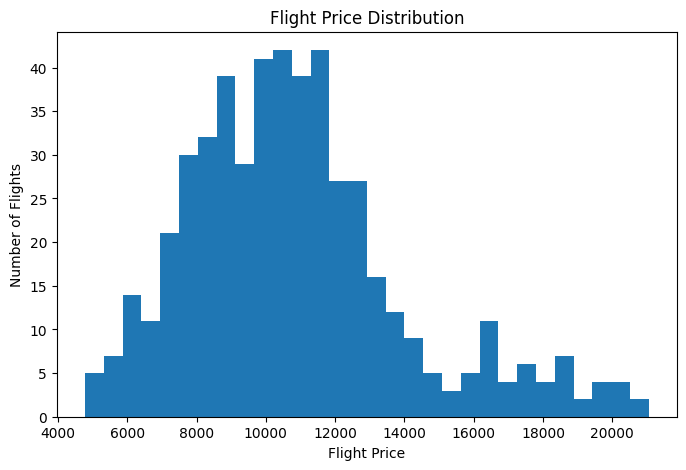

In [17]:
plt.figure(figsize=(8, 5))

plt.hist(df["Price"], bins=30)

plt.xlabel("Flight Price")
plt.ylabel("Number of Flights")
plt.title("Flight Price Distribution")

plt.show()

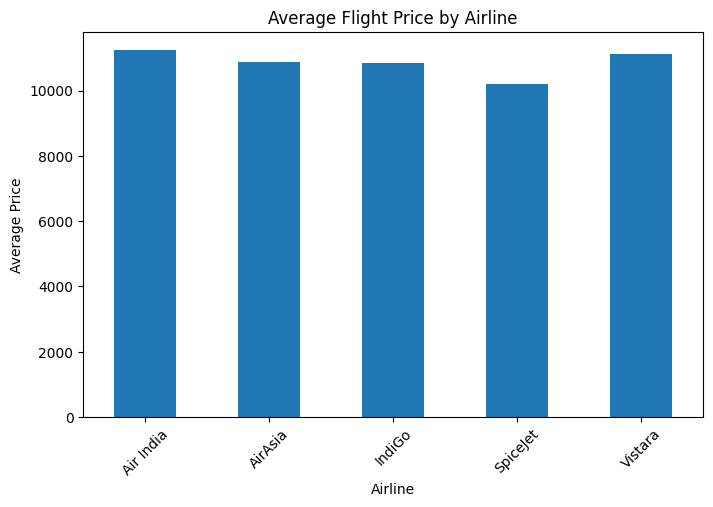

In [18]:
plt.figure(figsize=(8, 5))

df.groupby("Airline")["Price"].mean().plot(kind="bar")

plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.title("Average Flight Price by Airline")

plt.xticks(rotation=45)

plt.show()

In [19]:
X = df.drop("Price", axis=1)

y = df["Price"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Features:
['Airline', 'Source', 'Destination', 'Departure_Time', 'Duration_Hours', 'Total_Stops', 'Days_Left', 'Class']

Target:
Price


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (400, 8)
Testing data: (100, 8)


In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Airline",
    "Source",
    "Destination",
    "Departure_Time",
    "Class"
]

numerical_features = [
    "Duration_Hours",
    "Total_Stops",
    "Days_Left"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ],
    remainder="passthrough"
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [22]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:",
      X_train_processed.shape)

print("Testing data after preprocessing:",
      X_test_processed.shape)

Training data after preprocessing: (400, 26)
Testing data after preprocessing: (100, 26)


In [24]:
# Preprocess training and testing data

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

print("Training data after preprocessing:", X_train_processed.shape)
print("Testing data after preprocessing:", X_test_processed.shape)

Training data after preprocessing: (400, 26)
Testing data after preprocessing: (100, 26)
